In [3]:
import os
import sys
import json
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import sem
import os
os.environ["JAX_PLATFORMS"] = "cpu"
sys.path.append(os.path.abspath(".."))

def load_new_run_data(alg, suffix, seed, env_name, results_base_path="../results"):
    """
    Loads data from the specific folder: ../results/{alg}/{suffix}_s{seed}/{env_name}
    Note the '..' to go up from the /notebooks folder.
    """
    # 1. Construct the folder name for the seed
    run_folder = f"{suffix}_s{seed}"
    
    # 2. Join the paths
    # Result: ../results/cov_lstd/4_26_first_half_s0/Adventure-v5
    run_path = os.path.join(results_base_path, alg, run_folder, env_name)
    
    # Absolute paths are safer when working in notebooks
    run_path = os.path.abspath(run_path)
    
    config_path = os.path.join(run_path, "config.json")
    metrics_path = os.path.join(run_path, f"seed_{seed}_metrics.npz")
    
    if not os.path.exists(config_path):
        # This will now print the EXACT path it's looking for so you can verify
        raise FileNotFoundError(f"Config not found at {config_path}")
    
    with open(config_path, 'r') as f:
        config = json.load(f)
        
    if not os.path.exists(metrics_path):
        raise FileNotFoundError(f"Metrics not found at {metrics_path}")
        
    with np.load(metrics_path, allow_pickle=True) as data:
        metrics = {k: jnp.array(v) for k, v in data.items()}
        
    return config, metrics

config, metrics = load_new_run_data('cov_lstd', '4_29_norm_rho_feats', 0, 'MontezumaRevenge-v5')
config, metrics = load_new_run_data('cov_lstd', '4_29_norm_rho_and_lstd_feats', 0, 'MontezumaRevenge-v5')
config, metrics = load_new_run_data('cov_lstd', '4_29_continuing_leaky_high_reg', 0, 'MontezumaRevenge-v5')

# alg, suffix, seed, env_name, results_base_path="../results"

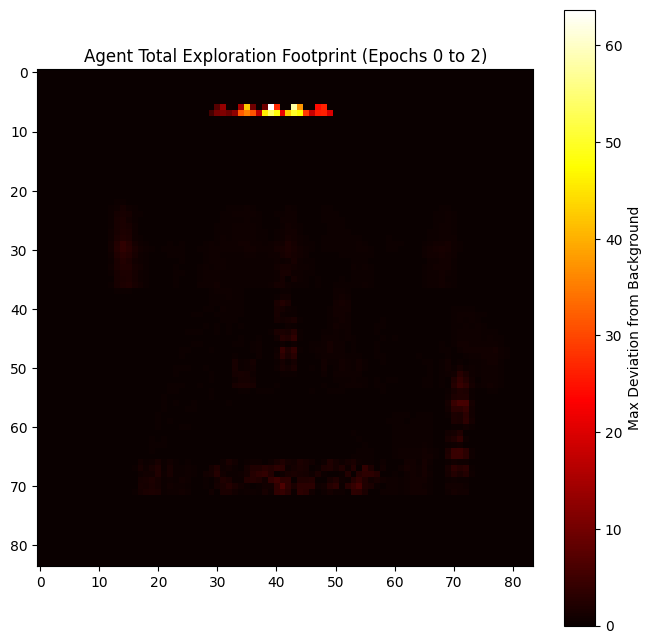

In [5]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

L = 2
# 1. Isolate the background (Epoch 0 is mostly just standing at spawn)
background = metrics['average_obs'][0]

# 2. Calculate absolute difference from the background for all L epochs
# Shape is (L, H, W)
diffs = jnp.abs(metrics['average_obs'][:L] - background)

# 3. Take the MAX across the time dimension instead of the sum/mean
footprint = jnp.max(diffs, axis=0)

# 4. Plot with a high-contrast colormap
plt.figure(figsize=(8, 8))
# 'hot' or 'magma' colormaps make the black background disappear and the agent pop
plt.imshow(footprint, cmap='hot', interpolation='nearest')
plt.title(f"Agent Total Exploration Footprint (Epochs 0 to {L})")
plt.colorbar(label="Max Deviation from Background")
plt.show()

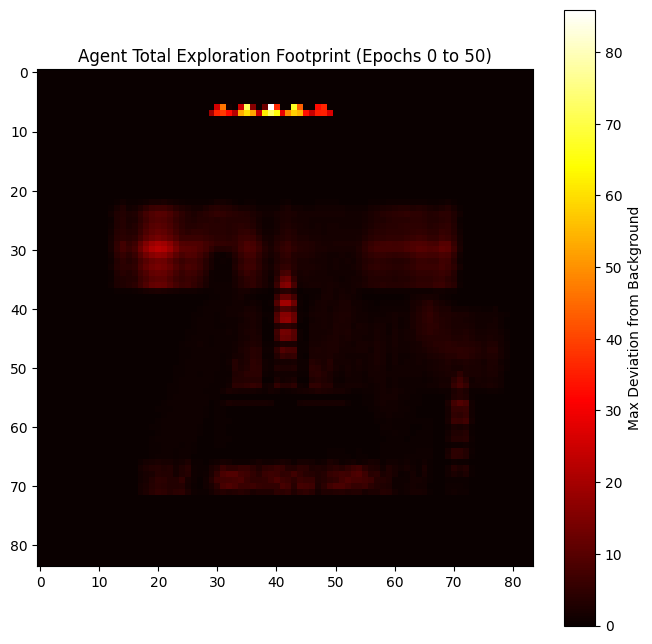

In [6]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

L = 50
# 1. Isolate the background (Epoch 0 is mostly just standing at spawn)
background = metrics['average_obs'][0]

# 2. Calculate absolute difference from the background for all L epochs
# Shape is (L, H, W)
diffs = jnp.abs(metrics['average_obs'][:L] - background)

# 3. Take the MAX across the time dimension instead of the sum/mean
footprint = jnp.max(diffs, axis=0)

# 4. Plot with a high-contrast colormap
plt.figure(figsize=(8, 8))
# 'hot' or 'magma' colormaps make the black background disappear and the agent pop
plt.imshow(footprint, cmap='hot', interpolation='nearest')
plt.title(f"Agent Total Exploration Footprint (Epochs 0 to {L})")
plt.colorbar(label="Max Deviation from Background")
plt.show()

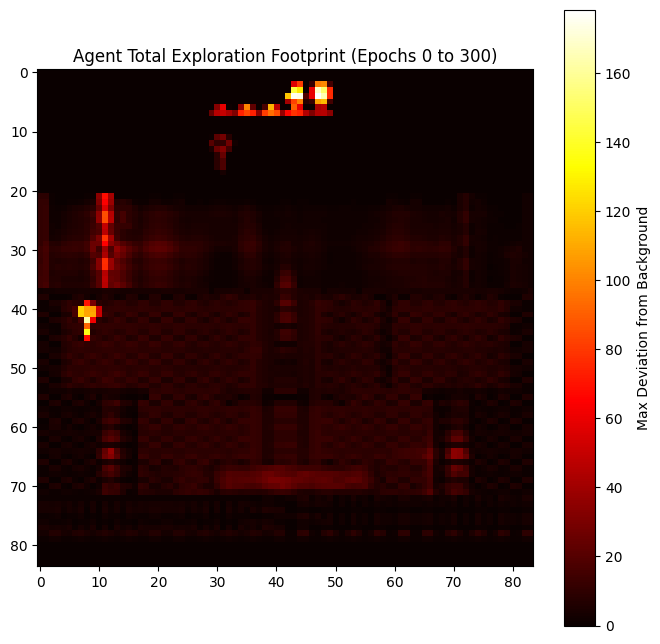

In [7]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

L = 300
# 1. Isolate the background (Epoch 0 is mostly just standing at spawn)
background = metrics['average_obs'][0]

# 2. Calculate absolute difference from the background for all L epochs
# Shape is (L, H, W)
diffs = jnp.abs(metrics['average_obs'][:L] - background)

# 3. Take the MAX across the time dimension instead of the sum/mean
footprint = jnp.max(diffs, axis=0)

# 4. Plot with a high-contrast colormap
plt.figure(figsize=(8, 8))
# 'hot' or 'magma' colormaps make the black background disappear and the agent pop
plt.imshow(footprint, cmap='hot', interpolation='nearest')
plt.title(f"Agent Total Exploration Footprint (Epochs 0 to {L})")
plt.colorbar(label="Max Deviation from Background")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


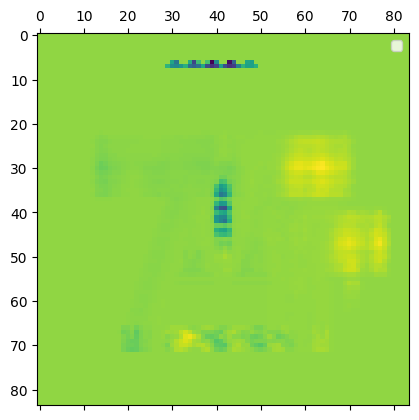

In [51]:
x1=50
x2=0
plt.matshow(metrics['average_obs'][x1]-metrics['average_obs'][x2], label=
'obs')
plt.legend()